In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
X, y = load_iris(return_X_y=True) # Load the Iris dataset and return the features (X) and target labels (y)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets

sc = StandardScaler() # Create an instance of the StandardScaler to standardize the features
X_tr = sc.fit_transform(X_tr) # Fit the scaler to the training data and transform it. This will standardize the features by removing the mean and scaling to unit variance.
X_te = sc.transform(X_te) # Transform the test data using the same scaler fitted on the training data. This ensures that the test data is standardized in the same way as the training data.
model = LogisticRegression(max_iter=200) # Create an instance of the LogisticRegression model with a maximum of 200 iterations for convergence. Logistic Regression is a linear model used for classification tasks.
model.fit(X_tr, y_tr) # Fit the Logistic Regression model to the training data (X_tr and y_tr). This will train the model to learn the relationship between the features and the target labels.
print("Accuracy:", accuracy_score(y_te, model.predict(X_te)))

Accuracy: 1.0


   Requests_per_sec  Packet_Size  Cluster  Prediction
0         57.450712   971.557472        0           0
1         47.926035  1012.156905        0           0
2         59.715328  1116.610249        0           0
3         72.845448  1110.760410        0           0
4         46.487699   624.466126        0           0
DDoS Cluster: 1


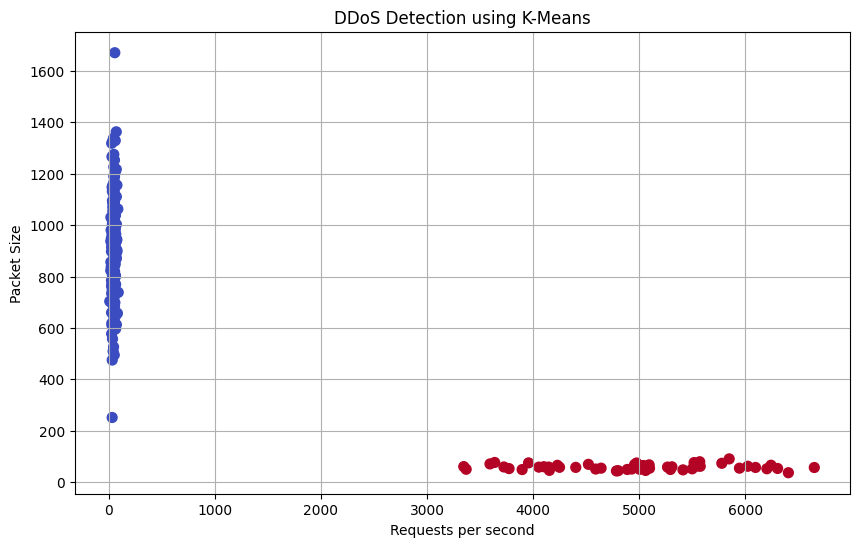

In [ ]:
np.random.seed(42)

normal_requests_per_sec = np.random.normal(50, 15, 200) # 50 yêu cầu mỗi giây với độ lệch chuẩn 15, tạo ra 200 mẫu
normal_packet_size = np.random.normal(900, 200, 200) # Kích thước gói tin trung bình 900 bytes với độ lệch chuẩn 200, tạo ra 200 mẫu

attack_requests = np.random.normal(5000, 800, 50) # 5000 yêu cầu mỗi giây với độ lệch chuẩn 800, tạo ra 50 mẫu
attack_packet_size = np.random.normal(60, 10, 50) # Kích thước gói tin trung bình 60 bytes với độ lệch chuẩn 10, tạo ra 50 mẫu

# Gộp dữ liệu
requests = np.concatenate([normal_requests_per_sec, attack_requests])
packet = np.concatenate([normal_packet_size, attack_packet_size])

# DataFrame
df = pd.DataFrame({
    'Requests_per_sec': requests,
    'Packet_Size': packet
})

# =========================
# CHUẨN HÓA DỮ LIỆU
# =========================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

# =========================
# K-MEANS
# =========================

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(scaled_data)

# =========================
# XÁC ĐỊNH CỤM DDoS
# =========================

cluster_means = df.groupby('Cluster')['Requests_per_sec'].mean() # Tính trung bình số lượng yêu cầu mỗi giây cho mỗi cụm

ddos_cluster = cluster_means.idxmax() # Xác định cụm có trung bình số lượng yêu cầu mỗi giây cao nhất, đây sẽ là cụm DDoS

df['Prediction'] = df['Cluster'].apply(
    lambda x: 1 if x == ddos_cluster else 0
) # Tạo cột 'Prediction' để đánh dấu các mẫu thuộc cụm DDoS (1) và không thuộc cụm DDoS (0)

# =========================
# HIỂN THỊ
# =========================

print(df.head())

# =========================
# VẼ BIỂU ĐỒ
# =========================

plt.figure(figsize=(10,6))

plt.scatter(
    df['Requests_per_sec'],
    df['Packet_Size'],
    c=df['Prediction'],
    cmap='coolwarm',
    s=50
)
# DDoS là màu đỏ, bình thường là màu xanh
print("DDoS Cluster:", ddos_cluster)


plt.xlabel("Requests per second")
plt.ylabel("Packet Size")
plt.title("DDoS Detection using K-Means")

plt.grid(True)
plt.show()

In [5]:
new_packet_per_sec = float(input("Enter requests per second: "))
new_packet_size = float(input("Enter packet size: "))

print(f"New sample - Requests per second: {new_packet_per_sec}, Packet size: {new_packet_size}")
new_sample = pd.DataFrame({
    'Requests_per_sec': [new_packet_per_sec],
    'Packet_Size': [new_packet_size]
})

# normalize bằng scaler cũ
new_sample_scaled = scaler.transform(new_sample)

# Predict
predicted_cluster = kmeans.predict(new_sample_scaled)[0]

print("Predicted Cluster:", predicted_cluster)


if predicted_cluster == ddos_cluster:
    print("DDoS DETECTED")
else:
    print("Normal Traffic")

New sample - Requests per second: 6000.0, Packet size: 20.0
Predicted Cluster: 1
DDoS DETECTED
